In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

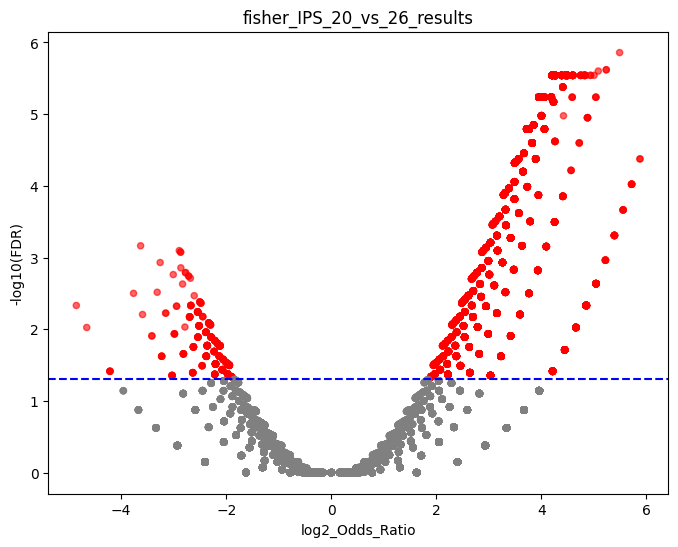

,otu,IPS_sig_group
2,IPR000015,20_year
3,IPR000021,20_year
9,IPR000035,20_year
10,IPR000036,20_year
16,IPR000059,20_year
...,...,...
16870,IPR056113,20_year
16880,IPR056174,20_year
16895,IPR056329,20_year
16896,IPR056338,20_year


In [2]:
df = pd.read_csv('/home/dcm/250513Pat_250728Pat_250930Pat/stats_out/fisher_IPS_20_vs_26_results.txt', sep ='\t')
#otu	Odds_Ratio	P-value	20_pos	20_neg	26_pos	26_neg	FDR_BH	ENTRY_AC	ENTRY_TYPE	ENTRY_NAME
# Thresholds

df["OR_corrected"] = (
    (df["20_pos"] + 0.5) * (df["26_neg"] + 0.5)
) / (
    (df["20_neg"] + 0.5) * (df["26_pos"] + 0.5)
)

df["log2_Odds_Ratio"] = np.log2(df["OR_corrected"])

# Transform p-values
df["neg_log10_pval"] = -np.log10(df["FDR_BH"])


# Define significance
pval_thresh = 0.05
df["significant"] = df["FDR_BH"] < pval_thresh

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    df["log2_Odds_Ratio"],
    df["neg_log10_pval"],
    c=df["significant"].map({True: "red", False: "grey"}),
    alpha=0.6,
    s=20
)

# Threshold lines
plt.axhline(-np.log10(pval_thresh), color="blue", linestyle="--")


plt.xlabel("log2_Odds_Ratio")
plt.ylabel("-log10(FDR)")
plt.title("fisher_IPS_20_vs_26_results")
plt.show()

#see how many sig IPS are enriched in 20 vs 26 year with pivot table
pd.crosstab(
    df["significant"],
    df["log2_Odds_Ratio"] > 0,
    rownames=["Significant"],
    colnames=["log2_OR > 0"]
)


#add new col to df that labels which group the IPS is enriched in
df["IPS_sig_group"] = np.where(
    df["significant"] == True,
    np.where(df["log2_Odds_Ratio"] > 0, "20_year", "26_year"),
    None  # or keep existing value
)

df_IPS_sig_group = df[['otu', 'IPS_sig_group']].dropna()

df_IPS_sig_group

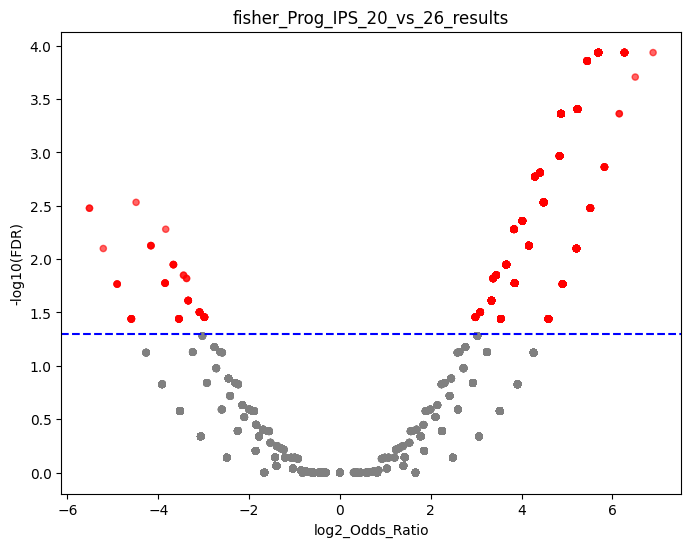

log2_OR > 0,False,True
Significant,,
False,4784,7565
True,92,3188


In [3]:
df = pd.read_csv('/home/dcm/250513Pat_250728Pat_250930Pat/stats_out/fisher_Prog_IPS_20_vs_26_results.txt', sep ='\t')
#otu	Odds_Ratio	P-value	20_pos	20_neg	26_pos	26_neg	FDR_BH	ENTRY_AC	ENTRY_TYPE	ENTRY_NAME
# Thresholds

df["OR_corrected"] = (
    (df["20_pos"] + 0.5) * (df["26_neg"] + 0.5)
) / (
    (df["20_neg"] + 0.5) * (df["26_pos"] + 0.5)
)

df["log2_Odds_Ratio"] = np.log2(df["OR_corrected"])

# Transform p-values
df["neg_log10_pval"] = -np.log10(df["FDR_BH"])


# Define significance
pval_thresh = 0.05
df["significant"] = df["FDR_BH"] < pval_thresh

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    df["log2_Odds_Ratio"],
    df["neg_log10_pval"],
    c=df["significant"].map({True: "red", False: "grey"}),
    alpha=0.6,
    s=20
)

# Threshold lines
plt.axhline(-np.log10(pval_thresh), color="blue", linestyle="--")


plt.xlabel("log2_Odds_Ratio")
plt.ylabel("-log10(FDR)")
plt.title("fisher_Prog_IPS_20_vs_26_results")
plt.show()

pd.crosstab(
    df["significant"],
    df["log2_Odds_Ratio"] > 0,
    rownames=["Significant"],
    colnames=["log2_OR > 0"]
)

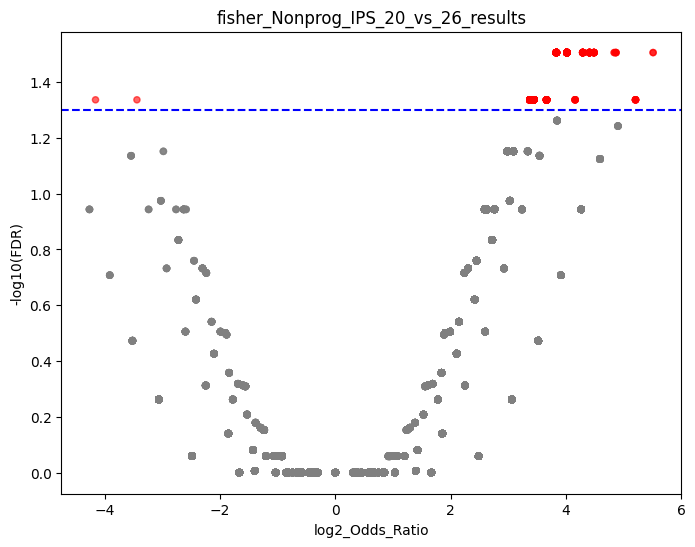

log2_OR > 0,False,True
Significant,,
False,5662,8708
True,2,723


In [4]:
df = pd.read_csv('/home/dcm/250513Pat_250728Pat_250930Pat/stats_out/fisher_Nonprog_IPS_20_vs_26_results.txt', sep ='\t')
#otu	Odds_Ratio	P-value	20_pos	20_neg	26_pos	26_neg	FDR_BH	ENTRY_AC	ENTRY_TYPE	ENTRY_NAME
# Thresholds

df["OR_corrected"] = (
    (df["20_pos"] + 0.5) * (df["26_neg"] + 0.5)
) / (
    (df["20_neg"] + 0.5) * (df["26_pos"] + 0.5)
)

df["log2_Odds_Ratio"] = np.log2(df["OR_corrected"])

# Transform p-values
df["neg_log10_pval"] = -np.log10(df["FDR_BH"])

# Define significance
pval_thresh = 0.05
df["significant"] = df["FDR_BH"] < pval_thresh

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    df["log2_Odds_Ratio"],
    df["neg_log10_pval"],
    c=df["significant"].map({True: "red", False: "grey"}),
    alpha=0.6,
    s=20
)

# Threshold lines
plt.axhline(-np.log10(pval_thresh), color="blue", linestyle="--")


plt.xlabel("log2_Odds_Ratio")
plt.ylabel("-log10(FDR)")
plt.title("fisher_Nonprog_IPS_20_vs_26_results")
plt.show()

pd.crosstab(
    df["significant"],
    df["log2_Odds_Ratio"] > 0,
    rownames=["Significant"],
    colnames=["log2_OR > 0"]
)

In [5]:
df = pd.read_csv('stats_out/annotations_signif_IPS_feature_ids.txt', sep = '\t', dtype=str)

In [6]:
len(df)

1599381

In [7]:
df.columns

Index(['Unnamed: 0', 'contig_id', 'feature_id', 'type', 'location', 'start',
       'stop', 'strand', 'function', 'aliases', 'plfam', 'pgfam', 'figfam',
       'evidence_codes', 'nucleotide_sequence', 'aa_sequence', 'qseqid_x',
       'qlen', 'sseqid', 'slen', 'qseq', 'sseq', 'evalue', 'bitscore',
       'pident', 'qcovhsp', 'salltitles', 'qseqid_y', 'taxid', 'file',
       'taxname', 'taxid_rep', 'phylum', 'class', 'order', 'family', 'genus',
       'species', 'fisher_IPS_20_vs_26_results',
       'fisher_Nonprog_IPS_20_vs_26_results',
       'fisher_Prog_IPS_20_vs_26_results', 'fisher_IPS_N_vs_P_results',
       'fisher_year_20_IPS_N_vs_P_results',
       'fisher_year_26_IPS_N_vs_P_results'],
      dtype='object')

In [9]:
df = pd.merge(df, df_IPS_sig_group, left_on ='fisher_IPS_20_vs_26_results', right_on ='otu', how ='left')
df

,Unnamed: 0,contig_id,feature_id,type,location,start,stop,strand,function,aliases,...,genus,species,fisher_IPS_20_vs_26_results,fisher_Nonprog_IPS_20_vs_26_results,fisher_Prog_IPS_20_vs_26_results,fisher_IPS_N_vs_P_results,fisher_year_20_IPS_N_vs_P_results,fisher_year_26_IPS_N_vs_P_results,otu,IPS_sig_group
0,2,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.3,CDS,NODE_1_length_1111386_cov_135.597736_1648-483,1648,1166,-,Acid shock protein precursor,NaN,...,Raoultella,Raoultella terrigena,IPR023497,NaN,IPR023497,NaN,NaN,NaN,IPR023497,20_year
1,5,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.6,CDS,NODE_1_length_1111386_cov_135.597736_4891-1374,4891,3518,-,Multidrug efflux transporter MdtK/NorM (MATE f...,NaN,...,Raoultella,Raoultella terrigena,IPR022913,NaN,IPR022913,NaN,NaN,NaN,IPR022913,20_year
2,11,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.12,CDS,NODE_1_length_1111386_cov_135.597736_10627-1026,10627,9602,-,Purine nucleotide synthesis repressor,NaN,...,Raoultella,Raoultella terrigena,IPR023588,NaN,IPR023588,NaN,NaN,NaN,IPR023588,20_year
3,12,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.13,CDS,NODE_1_length_1111386_cov_135.597736_10922+90,10922,11011,+,hypothetical protein,NaN,...,Raoultella,Raoultella terrigena,IPR047743,NaN,IPR047743,NaN,NaN,NaN,IPR047743,20_year
4,17,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.18,CDS,NODE_1_length_1111386_cov_135.597736_15352-648,15352,14705,-,Ribonuclease T,NaN,...,Raoultella,Raoultella terrigena,IPR005987,NaN,NaN,NaN,NaN,NaN,IPR005987,20_year
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1599376,52943,NODE_6944_length_1001_cov_8.335095,fig|2.65428.peg.52247,CDS,NODE_6944_length_1001_cov_8.335095_3+207,3,209,+,Cnu protein,NaN,...,Raoultella,Raoultella terrigena,IPR036666,NaN,IPR007985,NaN,NaN,NaN,IPR036666,20_year
1599377,52943,NODE_6944_length_1001_cov_8.335095,fig|2.65428.peg.52247,CDS,NODE_6944_length_1001_cov_8.335095_3+207,3,209,+,Cnu protein,NaN,...,Raoultella,Raoultella terrigena,IPR036666,NaN,IPR036666,NaN,NaN,NaN,IPR036666,20_year
1599378,52944,NODE_6944_length_1001_cov_8.335095,fig|2.65428.peg.52248,CDS,NODE_6944_length_1001_cov_8.335095_389+441,389,829,+,Inner membrane protein YdgK,NaN,...,Raoultella,Raoultella terrigena,IPR019690,NaN,IPR019690,NaN,NaN,NaN,IPR019690,20_year
1599379,52959,NODE_6952_length_1000_cov_8.826455,fig|2.65428.peg.52263,CDS,NODE_6952_length_1000_cov_8.826455_702-354,702,349,-,hypothetical protein,NaN,...,Raoultella,Raoultella terrigena,IPR045681,NaN,NaN,NaN,NaN,NaN,IPR045681,20_year


In [11]:
unique_items = df['fisher_IPS_20_vs_26_results'].dropna().unique()
len(unique_items)

5229

In [12]:
unique_items = df['species'].dropna().unique()
len(unique_items)

838

In [ ]:
################
### KEGG
###############

In [ ]:
df_genes = df.dropna(subset=['IPS_fisher_IPS_20_vs_26_results']).drop_duplicates(subset=['feature_id','aa_sequence'])

df_genes             

In [ ]:
fasta = (
    ">" + df_genes["feature_id"] + "\n" + df_genes["aa_sequence"]
).str.cat(sep="\n")

with open("output.fasta", "w") as f:
    f.write(fasta)

In [ ]:
#map aa sequences to KO --> run in terminal as off screen bc very slow / big database to search --> takes about 2-4 hrs to finish 400,000 sequences
#!/home/dcm/kofamscan/bin/kofam_scan-1.3.0/exec_annotation output.fasta -o KO.txt --cpu 90 -f mapper

In [ ]:
df_ko = pd.read_csv('KO.txt', sep = '\t', names=['feature_id', 'KO'])

In [ ]:
len(df_ko['KO'].dropna().unique())

In [ ]:
#https://www.kegg.jp/kegg/rest/keggapi.html#list
#get kegg mapping files for KO to pathways and modules

!wget -O kegg_pathways.txt https://rest.kegg.jp/list/pathway/
!wget -O kegg_modules.txt https://rest.kegg.jp/list/module/
!wget -O kegg_pathway_ko_links.txt https://rest.kegg.jp/link/ko/pathway
!wget -O kegg_module_ko_links.txt https://rest.kegg.jp/link/ko/module


In [ ]:
df_kegg_pathways = pd.read_csv('kegg_pathways.txt', sep ='\t', names = ['pathway', 'pathway_name'])

#print(df_kegg_pathways.head())

df_kegg_modules = pd.read_csv('kegg_modules.txt', sep ='\t', names = ['module', 'module_name'])

#print(df_kegg_modules.head())

df_kegg_pathway_ko_links = pd.read_csv('kegg_pathway_ko_links.txt', sep ='\t', names = ['pathway', 'KO'])

df_kegg_pathway_ko_links['pathway'] = df_kegg_pathway_ko_links['pathway'].str.replace('path:', '', regex=False)
df_kegg_pathway_ko_links['KO'] = df_kegg_pathway_ko_links['KO'].str.replace('ko:', '', regex=False)

#print(df_kegg_pathway_ko_links.head())

df_kegg_module_ko_links = pd.read_csv('kegg_module_ko_links.txt', sep ='\t', names = ['module', 'KO'])

df_kegg_module_ko_links['module'] = df_kegg_module_ko_links['module'].str.replace('md:', '', regex=False)
df_kegg_module_ko_links['KO'] = df_kegg_module_ko_links['KO'].str.replace('ko:', '', regex=False)

#print(df_kegg_module_ko_links.head())

dfm = pd.merge(df_ko, df_kegg_pathway_ko_links, on = 'KO', how = 'left')
dfm = pd.merge(dfm, df_kegg_pathways, on = 'pathway', how = 'left')
dfm = pd.merge(dfm, df_kegg_module_ko_links, on = 'KO', how = 'left')
dfm = pd.merge(dfm, df_kegg_modules, on = 'module', how = 'left')


dfm

In [ ]:
pivot_df = (
    dfm.dropna(subset=['pathway_name'])
       .pivot_table(
           index='pathway_name',
           aggfunc='size',
           fill_value=0
       )
       .sort_values(ascending=False)
       .reset_index(name='count')
)

pivot_df 

In [ ]:
#merge KO pathways to main df
dfm = pd.merge(df, dfm, on = 'feature_id', how = 'left')

dfm

In [ ]:
dfm.columns

In [ ]:
filtered_df = dfm[dfm['IPS_sig_group']== '20_year']
filtered_df

unique_species= len(filtered_df['species'].unique())
unique_species

unique_genes = len(filtered_df['feature_id'].unique())
unique_genes

pivot_df = (
    filtered_df.dropna(subset=['module_name'])
               .groupby(['module_name', 'species'])
               .size()       # count of each species per module
               .div(unique_genes)  # divide by your number
               .unstack(fill_value=0)  # make species columns
)
pivot_df

long_df = pivot_df.reset_index().melt(
    id_vars='module_name',       # keep 'module' as identifier
    var_name='species',     # name of the column for species
    value_name='ratio'      # name of the column for the values (size / unique_genes)
)

long_df

# get top representative species

# Step 3: compute total abundance per species
species_totals = long_df.groupby('species')['ratio'].sum()

# Step 4: identify top 10 species
top_species = species_totals.nlargest(10).index

# Step 5: group species not in top 10 into 'Other'
long_df['species_grouped'] = long_df['species'].where(
    long_df['species'].isin(top_species),
    'Other'
)

# Step 6: aggregate ratios per module and grouped species
final_long_df = (
    long_df.groupby(['module_name', 'species_grouped'])['ratio']
           .sum()
           .reset_index()
)

# Optional Step 7: pivot back to wide format (top 10 + Other as columns)
final_wide_df = final_long_df.pivot(
    index='module_name',
    columns='species_grouped',
    values='ratio'
).fillna(0)


#get top most prevalent pathways
final_wide_df_top25 = (
    final_wide_df.assign(total=final_wide_df.sum(axis=1))
                 .sort_values('total', ascending=True)  # highest totals first
                 .tail(25)                               # keep top 25 rows
                 .drop(columns='total')                  # remove helper column
)

# convert fractions to percentages
final_wide_df_top25 = final_wide_df_top25 * 100

# Step 2: plot
final_wide_df_top25.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

species_totals = final_wide_df_top25.sum().sort_values(ascending=False)


# Step 2: reorder columns by total abundance
final_wide_df_top25_sorted_cols = final_wide_df_top25[species_totals.index]


# Step 3: plot
final_wide_df_top25_sorted_cols.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)



In [ ]:
filtered_df = dfm[dfm['IPS_sig_group']== '26_year']
filtered_df

unique_species= len(filtered_df['species'].unique())
unique_species

unique_genes = len(filtered_df['feature_id'].unique())
unique_genes

pivot_df = (
    filtered_df.dropna(subset=['module_name'])
               .groupby(['module_name', 'species'])
               .size()       # count of each species per module
               .div(unique_genes)  # divide by your number
               .unstack(fill_value=0)  # make species columns
)
pivot_df

long_df = pivot_df.reset_index().melt(
    id_vars='module_name',       # keep 'module' as identifier
    var_name='species',     # name of the column for species
    value_name='ratio'      # name of the column for the values (size / unique_genes)
)

long_df

# get top representative species

# Step 3: compute total abundance per species
species_totals = long_df.groupby('species')['ratio'].sum()

# Step 4: identify top 10 species
top_species = species_totals.nlargest(10).index

# Step 5: group species not in top 10 into 'Other'
long_df['species_grouped'] = long_df['species'].where(
    long_df['species'].isin(top_species),
    'Other'
)

# Step 6: aggregate ratios per module and grouped species
final_long_df = (
    long_df.groupby(['module_name', 'species_grouped'])['ratio']
           .sum()
           .reset_index()
)

# Optional Step 7: pivot back to wide format (top 10 + Other as columns)
final_wide_df = final_long_df.pivot(
    index='module_name',
    columns='species_grouped',
    values='ratio'
).fillna(0)


#get top most prevalent pathways
final_wide_df_top25 = (
    final_wide_df.assign(total=final_wide_df.sum(axis=1))
                 .sort_values('total', ascending=True)  # highest totals first
                 .tail(25)                               # keep top 25 rows
                 .drop(columns='total')                  # remove helper column
)

# convert fractions to percentages
final_wide_df_top25 = final_wide_df_top25 * 100

# Step 2: plot
final_wide_df_top25.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

species_totals = final_wide_df_top25.sum().sort_values(ascending=False)

# Step 2: reorder columns by total abundance
final_wide_df_top25_sorted_cols = final_wide_df_top25[species_totals.index]

# Step 3: plot
final_wide_df_top25_sorted_cols.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)



In [ ]:
################
### VFDB
###############

In [ ]:
df.columns

In [ ]:
#filter for only VF with >= 35% sequence identity
df['pident'] = pd.to_numeric(df['pident'], errors='coerce')


df_VF = df[df['pident'] >= 35]


In [ ]:
#pivot IPS by VFDB, lists all VF gene expect nan

pivot_df = (
    df_VF.dropna(subset=['fisher_IPS_20_vs_26_results'])
      .pivot_table(
          index='fisher_IPS_20_vs_26_results',
          values='salltitles',
          aggfunc=lambda x: list(x.unique())
      )
)
pivot_df = pivot_df[~pivot_df['salltitles'].apply(lambda x: len(x) == 1 and (x[0] is np.nan or x[0] == 'nan'))]
pivot_df.to_csv('out.txt', sep = '\t')

In [ ]:
#pivot IPS by VFDB, lists top two VF gene

pivot_df = (
    df_VF.dropna(subset=['fisher_IPS_20_vs_26_results'])
      .pivot_table(
          index='fisher_IPS_20_vs_26_results',
          values='salltitles',
          aggfunc=lambda x: [item for item, count in Counter(x).most_common(2)]
      )
)
pivot_df = pivot_df[~pivot_df['salltitles'].apply(lambda x: len(x) == 1 and (x[0] is np.nan or x[0] == 'nan'))]

pivot_df

pivot_df.to_csv('out.txt', sep = '\t')

In [ ]:
#pivot IPS by VFDB, lists top  VF gene

pivot_df = (
    df_VF.dropna(subset=['fisher_IPS_20_vs_26_results'])
      .pivot_table(
          index='fisher_IPS_20_vs_26_results',
          values='salltitles',
          aggfunc=lambda x: Counter(x.dropna()).most_common(1)[0][0] if len(x.dropna()) > 0 else None
      )
)
pivot_df

In [ ]:
pivot_df = pivot_df.reset_index()
pivot_df = pivot_df.rename(columns={'salltitles': 'VF_consensus'})
pivot_df

In [ ]:
dfm = pd.merge(df, pivot_df, on = 'fisher_IPS_20_vs_26_results', how = 'left')

In [ ]:
# for feature_ids with <35% VF similiarity, need to remove VF_consensus label
dfm.loc[dfm['pident'] < 35, 'VF_consensus'] = np.nan


In [ ]:
dfm[dfm['pident'] < 35]

In [ ]:
filtered_df = dfm[dfm['IPS_sig_group']== '20_year']
filtered_df

unique_species= len(filtered_df['species'].unique())
unique_species

unique_genes = len(filtered_df['feature_id'].unique())
unique_genes

pivot_df = (
    filtered_df.dropna(subset=['VF_consensus'])
               .groupby(['VF_consensus', 'species'])
               .size()       # count of each species per module
               .div(unique_genes)  # divide by your number
               .unstack(fill_value=0)  # make species columns
)
pivot_df

long_df = pivot_df.reset_index().melt(
    id_vars='VF_consensus',       # keep 'module' as identifier
    var_name='species',     # name of the column for species
    value_name='ratio'      # name of the column for the values (size / unique_genes)
)

long_df

# get top representative species

# Step 3: compute total abundance per species
species_totals = long_df.groupby('species')['ratio'].sum()

# Step 4: identify top 10 species
top_species = species_totals.nlargest(10).index

# Step 5: group species not in top 10 into 'Other'
long_df['species_grouped'] = long_df['species'].where(
    long_df['species'].isin(top_species),
    'Other'
)

# Step 6: aggregate ratios per module and grouped species
final_long_df = (
    long_df.groupby(['VF_consensus', 'species_grouped'])['ratio']
           .sum()
           .reset_index()
)

# Optional Step 7: pivot back to wide format (top 10 + Other as columns)
final_wide_df = final_long_df.pivot(
    index='VF_consensus',
    columns='species_grouped',
    values='ratio'
).fillna(0)


#get top most prevalent pathways
final_wide_df_top25 = (
    final_wide_df.assign(total=final_wide_df.sum(axis=1))
                 .sort_values('total', ascending=True)  # highest totals first
                 .tail(10)                               # keep top 25 rows
                 .drop(columns='total')                  # remove helper column
)

final_wide_df_top25 = final_wide_df_top25 * 100


# Step 2: plot
final_wide_df_top25.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

species_totals = final_wide_df_top25.sum().sort_values(ascending=False)

# Step 2: reorder columns by total abundance
final_wide_df_top25_sorted_cols = final_wide_df_top25[species_totals.index]

# Step 3: plot
final_wide_df_top25_sorted_cols.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

In [ ]:
filtered_df = dfm[dfm['IPS_sig_group']== '26_year']
filtered_df

unique_species= len(filtered_df['species'].unique())
unique_species

unique_genes = len(filtered_df['feature_id'].unique())
unique_genes

pivot_df = (
    filtered_df.dropna(subset=['VF_consensus'])
               .groupby(['VF_consensus', 'species'])
               .size()       # count of each species per module
               .div(unique_genes)  # divide by your number
               .unstack(fill_value=0)  # make species columns
)
pivot_df

long_df = pivot_df.reset_index().melt(
    id_vars='VF_consensus',       # keep 'module' as identifier
    var_name='species',     # name of the column for species
    value_name='ratio'      # name of the column for the values (size / unique_genes)
)

long_df

# get top representative species

# Step 3: compute total abundance per species
species_totals = long_df.groupby('species')['ratio'].sum()

# Step 4: identify top 10 species
top_species = species_totals.nlargest(10).index

# Step 5: group species not in top 10 into 'Other'
long_df['species_grouped'] = long_df['species'].where(
    long_df['species'].isin(top_species),
    'Other'
)

# Step 6: aggregate ratios per module and grouped species
final_long_df = (
    long_df.groupby(['VF_consensus', 'species_grouped'])['ratio']
           .sum()
           .reset_index()
)

# Optional Step 7: pivot back to wide format (top 10 + Other as columns)
final_wide_df = final_long_df.pivot(
    index='VF_consensus',
    columns='species_grouped',
    values='ratio'
).fillna(0)


#get top most prevalent pathways
final_wide_df_top25 = (
    final_wide_df.assign(total=final_wide_df.sum(axis=1))
                 .sort_values('total', ascending=True)  # highest totals first
                 .tail(10)                               # keep top 25 rows
                 .drop(columns='total')                  # remove helper column
)

final_wide_df_top25 = final_wide_df_top25 * 100


# Step 2: plot
final_wide_df_top25.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

species_totals = final_wide_df_top25.sum().sort_values(ascending=False)

# Step 2: reorder columns by total abundance
final_wide_df_top25_sorted_cols = final_wide_df_top25[species_totals.index]

# Step 3: plot
final_wide_df_top25_sorted_cols.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

In [ ]:
################
### IPS 
###############

In [ ]:
#https://ftp.ebi.ac.uk/pub/databases/interpro/releases/latest/entry.list
#!wget -O IPS_metadata.txt https://ftp.ebi.ac.uk/pub/databases/interpro/releases/latest/entry.list

In [ ]:
df_IPS_meta = pd.read_csv('IPS_metadata.txt', sep = '\t')


In [ ]:
dfm = pd.merge(df, df_IPS_meta, left_on = 'fisher_IPS_20_vs_26_results', right_on = 'ENTRY_AC', how = 'left')

In [ ]:
filtered_df = dfm[dfm['IPS_sig_group']== '20_year']
filtered_df

unique_species= len(filtered_df['species'].unique())
unique_species

unique_genes = len(filtered_df['feature_id'].unique())
unique_genes

pivot_df = (
    filtered_df.dropna(subset=['ENTRY_NAME'])
               .groupby(['ENTRY_NAME', 'species'])
               .size()       # count of each species per module
               .div(unique_genes)  # divide by your number
               .unstack(fill_value=0)  # make species columns
)
pivot_df

long_df = pivot_df.reset_index().melt(
    id_vars='ENTRY_NAME',       # keep 'module' as identifier
    var_name='species',     # name of the column for species
    value_name='ratio'      # name of the column for the values (size / unique_genes)
)

long_df

# get top representative species

# Step 3: compute total abundance per species
species_totals = long_df.groupby('species')['ratio'].sum()

# Step 4: identify top 10 species
top_species = species_totals.nlargest(10).index

# Step 5: group species not in top 10 into 'Other'
long_df['species_grouped'] = long_df['species'].where(
    long_df['species'].isin(top_species),
    'Other'
)

# Step 6: aggregate ratios per module and grouped species
final_long_df = (
    long_df.groupby(['ENTRY_NAME', 'species_grouped'])['ratio']
           .sum()
           .reset_index()
)

# Optional Step 7: pivot back to wide format (top 10 + Other as columns)
final_wide_df = final_long_df.pivot(
    index='ENTRY_NAME',
    columns='species_grouped',
    values='ratio'
).fillna(0)


#get top most prevalent pathways
final_wide_df_top25 = (
    final_wide_df.assign(total=final_wide_df.sum(axis=1))
                 .sort_values('total', ascending=True)  # highest totals first
                 .tail(25)                               # keep top 25 rows
                 .drop(columns='total')                  # remove helper column
)

# Step 2: plot
final_wide_df_top25.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

species_totals = final_wide_df_top25.sum().sort_values(ascending=False)

final_wide_df_top25 = final_wide_df_top25 * 100


# Step 2: reorder columns by total abundance
final_wide_df_top25_sorted_cols = final_wide_df_top25[species_totals.index]

# Step 3: plot
final_wide_df_top25_sorted_cols.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

In [ ]:
filtered_df = dfm[dfm['IPS_sig_group']== '26_year']
filtered_df

unique_species= len(filtered_df['species'].unique())
unique_species

unique_genes = len(filtered_df['feature_id'].unique())
unique_genes

pivot_df = (
    filtered_df.dropna(subset=['ENTRY_NAME'])
               .groupby(['ENTRY_NAME', 'species'])
               .size()       # count of each species per module
               .div(unique_genes)  # divide by your number
               .unstack(fill_value=0)  # make species columns
)
pivot_df

long_df = pivot_df.reset_index().melt(
    id_vars='ENTRY_NAME',       # keep 'module' as identifier
    var_name='species',     # name of the column for species
    value_name='ratio'      # name of the column for the values (size / unique_genes)
)

long_df

# get top representative species

# Step 3: compute total abundance per species
species_totals = long_df.groupby('species')['ratio'].sum()

# Step 4: identify top 10 species
top_species = species_totals.nlargest(10).index

# Step 5: group species not in top 10 into 'Other'
long_df['species_grouped'] = long_df['species'].where(
    long_df['species'].isin(top_species),
    'Other'
)

# Step 6: aggregate ratios per module and grouped species
final_long_df = (
    long_df.groupby(['ENTRY_NAME', 'species_grouped'])['ratio']
           .sum()
           .reset_index()
)

# Optional Step 7: pivot back to wide format (top 10 + Other as columns)
final_wide_df = final_long_df.pivot(
    index='ENTRY_NAME',
    columns='species_grouped',
    values='ratio'
).fillna(0)


#get top most prevalent pathways
final_wide_df_top25 = (
    final_wide_df.assign(total=final_wide_df.sum(axis=1))
                 .sort_values('total', ascending=True)  # highest totals first
                 .tail(25)                               # keep top 25 rows
                 .drop(columns='total')                  # remove helper column
)

# Step 2: plot
final_wide_df_top25.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

species_totals = final_wide_df_top25.sum().sort_values(ascending=False)

final_wide_df_top25 = final_wide_df_top25 * 100


# Step 2: reorder columns by total abundance
final_wide_df_top25_sorted_cols = final_wide_df_top25[species_totals.index]

# Step 3: plot
final_wide_df_top25_sorted_cols.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

In [ ]:
######
## CARD
######

In [13]:
headers = [
    "qseqid",
    "qlen",
    "sseqid",
    "slen",
    "qseq",
    "sseq",
    "evalue",
    "bitscore",
    "pident",
    "qcovhsp",
    "salltitles",
]

df_card = pd.read_csv('CARD_diamond/CARD_cat.txt', sep = '\t', names = headers)
df_card["ARO Accession"] = df_card["sseqid"].str.extract(r"(ARO:\d+)")
df_card_meta = pd.read_csv('/home/dcm/bioinformatic_scripts/blast_databases/CARD-v4.0.1/aro_index.tsv', sep = '\t')
dfm = pd.merge(df_card, df_card_meta, how = 'left', on = "ARO Accession")
dfm

,qseqid,qlen,sseqid,slen,qseq,sseq,evalue,bitscore,pident,qcovhsp,...,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,fig|2.65351.peg.6,457,gb|ADO96486.1|ARO:3003953|hmrM,464,MQKYFIEARQLLALAIPVILAQVAQTSMGFVDTVMAGGYSATDMAA...,LSQYHTDIKKLIKISLPILLAQIAQNSMGLADTIMAGRVSSTDMAA...,4.180000e-139,405.0,45.9,99.3,...,5260,2425,hmrM,hmrM,ADO96486.1,CP002276.1,multidrug and toxic compound extrusion (MATE) ...,disinfecting agents and antiseptics;fluoroquin...,antibiotic efflux,hmrM
1,fig|2.65351.peg.10,394,gb|ALV80601.1|ARO:3003801|bcr-1,402,QPGKGFLVWLAGLSVLGFLATDMYLPAFSAIQQDLNTSAASVSASL...,QVGSGERRLLLLLSALVAFGPLSIDMYLPSLPAIAADLGASDAQVQ...,1.090000e-40,146.0,33.6,79.7,...,4627,2303,bcr-1,bcr-1,ALV80601.1,CP012901.1,major facilitator superfamily (MFS) antibiotic...,bicyclomycin-like antibiotic,antibiotic efflux,bcr-1
2,fig|2.65351.peg.14,388,gb|AAB36568.1|ARO:3002700|cmlv,436,LAIGAFGIGTTEFSPMGLLPVIAKGVDVSIPAAGMLISAYAIGVMV...,LGLSAFALGTSEFMLSGLVPPIAEDMNVSIPRAGLLISAFAIGMVV...,2.080000e-62,204.0,35.5,97.2,...,82,703,cmlv,cmlv,AAB36568.1,U09991.1,chloramphenicol phosphotransferase,phenicol antibiotic,antibiotic inactivation,cmlv
3,fig|2.65351.peg.19,135,gb|BAJ10053.1|ARO:3002874|FosC2,132,HTMLRVGDLQRSIEFYTNVLGMKLLRTSENTEYKYSLAFVGYGEES...,HITIAVSDLERSVEFYTRLLGMKAHVRWDSGAYLSLEATWICLSCD...,5.170000e-06,40.8,28.2,88.1,...,580,2060,FosC2,FosC2,BAJ10053.1,AB522969.1,fosC phosphotransferase family,phosphonic acid antibiotic,antibiotic inactivation,FosC2
4,fig|2.65351.peg.36,298,gb|AAF40763.1|ARO:3003961|farA,384,TRDGKVRAEQVGITPQVSGSILQLNVRDNQLVKAGDVLFTIDDTPY...,TEDAYVAGRVVQVTPQKGGTVRKVLHDDTDAVKKGDVLAVLDDDND...,3.970000e-23,95.5,30.6,82.2,...,5478,2428,farA,farA,AAF40763.1,AE002098.2,major facilitator superfamily (MFS) antibiotic...,antibacterial free fatty acids,antibiotic efflux,farA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217435,fig|2.65428.peg.52003,180,gb|AET10444.1|ARO:3004032|tetA(46),574,LLLLDEPLSALDARIRKHLREQIRRIQRELNLTAIFVTHDQEEALT...,LLLLDDSLSAVDAKTEQAIIDTIQKERKDKTTIIVSHRLSAVHQAD...,4.700000e-05,40.4,36.6,39.4,...,3976,2643,tetA(46),tetA(46),AET10444.1,HQ652506.1,ATP-binding cassette (ABC) antibiotic efflux pump,tetracycline antibiotic,antibiotic efflux,tetA(46)
217436,fig|2.65428.peg.52013,273,gb|VWQ04088.1|ARO:3005041|mlaF,269,MIEIKEVNKFYGQNQVLTDINLKINDGEIFGIIGHSGAGKSTILRC...,LVDMRDVSFTRGNRCIFDNISLTVPRGKITAIMGPSGIGKTTLLRL...,3.970000e-32,117.0,28.7,86.4,...,6077,3784,mlaF,mlaF,VWQ04088.1,LR730402.1,ATP-binding cassette (ABC) antibiotic efflux pump,glycopeptide antibiotic;oxazolidinone antibiotic,antibiotic efflux,mlaF
217437,fig|2.65428.peg.52028,258,gb|VWQ04088.1|ARO:3005041|mlaF,269,VLENINLRLRPGESVALLGPSGCGKSTLLRLLAGLEALQSGQVQID...,IFDNISLTVPRGKITAIMGPSGIGKTTLLRLIGGQIAPDHGEILFD...,2.590000e-23,93.2,31.0,72.9,...,6077,3784,mlaF,mlaF,VWQ04088.1,LR730402.1,ATP-binding cassette (ABC) antibiotic efflux pump,glycopeptide antibiotic;oxazolidinone antibiotic,antibiotic efflux,mlaF
217438,fig|2.65428.peg.52173,246,gb|CAG39568.1|ARO:3003285|Saur_rpoB_RIF,1183,QVGKRTRYTYAKINEVIKMPHLLDIQRKSYEWFLESGLQNIFNDIS...,QYGRHRKRRNYARISEVLELPNLIEIQTKSYEWFLREGLIEMFRDI...,5.460000e-88,280.0,59.1,98.0,...,5399,90,Staphylococcus aureus rpoB mutants conferring ...,Staphylococcus aureus rpoB mutants conferring ...,CAG39568.1,BX571856.1,rifamycin-resistant beta-subunit of RNA polyme...,peptide antibiotic;rifamycin antibiotic,antibiotic target alteration;antibiotic target...,Saur_rpoB_RIF


In [ ]:
df = pd.read_csv('/home/dcm//250513Pat_250728Pat_250930Pat/VFDB_diamond/cat_VFDB_out_meta_ips_sig.txt', sep = '\t', dtype=str)
df = pd.merge(df, df_IPS_sig_group, left_on ='IPS_fisher_IPS_20_vs_26_results', right_on ='otu', how ='left')
cols_to_drop = [
    'qlen', 'sseqid', 'slen', 'qseq', 'sseq', 'evalue', 'bitscore',
    'pident', 'qcovhsp', 'salltitles', 'qseqid_y', 'qseqid_x'
]

df = df.drop(columns=cols_to_drop)
df

In [14]:
dfm = pd.merge (df, dfm, left_on = 'feature_id', right_on = 'qseqid', how = 'left')

In [15]:
dfm.columns

Index(['Unnamed: 0', 'contig_id', 'feature_id', 'type', 'location', 'start',
       'stop', 'strand', 'function', 'aliases', 'plfam', 'pgfam', 'figfam',
       'evidence_codes', 'nucleotide_sequence', 'aa_sequence', 'qseqid_x',
       'qlen_x', 'sseqid_x', 'slen_x', 'qseq_x', 'sseq_x', 'evalue_x',
       'bitscore_x', 'pident_x', 'qcovhsp_x', 'salltitles_x', 'qseqid_y',
       'taxid', 'file', 'taxname', 'taxid_rep', 'phylum', 'class', 'order',
       'family', 'genus', 'species', 'fisher_IPS_20_vs_26_results',
       'fisher_Nonprog_IPS_20_vs_26_results',
       'fisher_Prog_IPS_20_vs_26_results', 'fisher_IPS_N_vs_P_results',
       'fisher_year_20_IPS_N_vs_P_results',
       'fisher_year_26_IPS_N_vs_P_results', 'otu', 'IPS_sig_group', 'qseqid',
       'qlen_y', 'sseqid_y', 'slen_y', 'qseq_y', 'sseq_y', 'evalue_y',
       'bitscore_y', 'pident_y', 'qcovhsp_y', 'salltitles_y', 'ARO Accession',
       'CVTERM ID', 'Model Sequence ID', 'Model ID', 'Model Name', 'ARO Name',
       'Protei

In [16]:
#filter for only VF with >= 75% sequence identity
dfm['pident_y'] = pd.to_numeric(dfm['pident_y'], errors='coerce')


df_CARD = dfm[dfm['pident_y'] >= 75]

In [17]:
#pivot IPS by VFDB, lists top  VF gene

pivot_df = (
    df_CARD.dropna(subset=['fisher_IPS_20_vs_26_results'])
      .pivot_table(
          index='fisher_IPS_20_vs_26_results',
          values='ARO Name',
          aggfunc=lambda x: Counter(x.dropna()).most_common(1)[0][0] if len(x.dropna()) > 0 else None
      )
)
pivot_df


pivot_df = pivot_df.reset_index()
pivot_df = pivot_df.rename(columns={'salltitles_y': 'ARO Name'})
pivot_df

,fisher_IPS_20_vs_26_results,ARO Name
0,IPR000274,Escherichia coli cyaA with mutation conferring...
1,IPR000498,OmpA
2,IPR000755,vanX gene in vanF cluster
3,IPR001018,L1 beta-lactamase
4,IPR001586,ACT-156
...,...,...
99,IPR051549,rphB
100,IPR051808,Neisseria gonorrhoeae pilQ gene conferring res...
101,IPR052023,kdpD
102,IPR052336,mlaD


In [18]:
dfm = pd.merge(dfm, pivot_df, on = 'fisher_IPS_20_vs_26_results', how = 'left')

# for feature_ids with <35% VF similiarity, need to remove VF_consensus label
dfm.loc[dfm['pident_y'] < 75, 'VF_consensus'] = np.nan

In [19]:
dfm

,Unnamed: 0,contig_id,feature_id,type,location,start,stop,strand,function,aliases,...,Model Name,ARO Name_x,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,ARO Name_y,VF_consensus
0,2,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.3,CDS,NODE_1_length_1111386_cov_135.597736_1648-483,1648,1166,-,Acid shock protein precursor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.6,CDS,NODE_1_length_1111386_cov_135.597736_4891-1374,4891,3518,-,Multidrug efflux transporter MdtK/NorM (MATE f...,NaN,...,hmrM,hmrM,ADO96486.1,CP002276.1,multidrug and toxic compound extrusion (MATE) ...,disinfecting agents and antiseptics;fluoroquin...,antibiotic efflux,hmrM,NaN,NaN
2,11,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.12,CDS,NODE_1_length_1111386_cov_135.597736_10627-1026,10627,9602,-,Purine nucleotide synthesis repressor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.13,CDS,NODE_1_length_1111386_cov_135.597736_10922+90,10922,11011,+,hypothetical protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17,NODE_1_length_1111386_cov_135.597736,fig|2.65351.peg.18,CDS,NODE_1_length_1111386_cov_135.597736_15352-648,15352,14705,-,Ribonuclease T,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1599796,52943,NODE_6944_length_1001_cov_8.335095,fig|2.65428.peg.52247,CDS,NODE_6944_length_1001_cov_8.335095_3+207,3,209,+,Cnu protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1599797,52943,NODE_6944_length_1001_cov_8.335095,fig|2.65428.peg.52247,CDS,NODE_6944_length_1001_cov_8.335095_3+207,3,209,+,Cnu protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1599798,52944,NODE_6944_length_1001_cov_8.335095,fig|2.65428.peg.52248,CDS,NODE_6944_length_1001_cov_8.335095_389+441,389,829,+,Inner membrane protein YdgK,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1599799,52959,NODE_6952_length_1000_cov_8.826455,fig|2.65428.peg.52263,CDS,NODE_6952_length_1000_cov_8.826455_702-354,702,349,-,hypothetical protein,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: ylabel='ARO Name_y'>

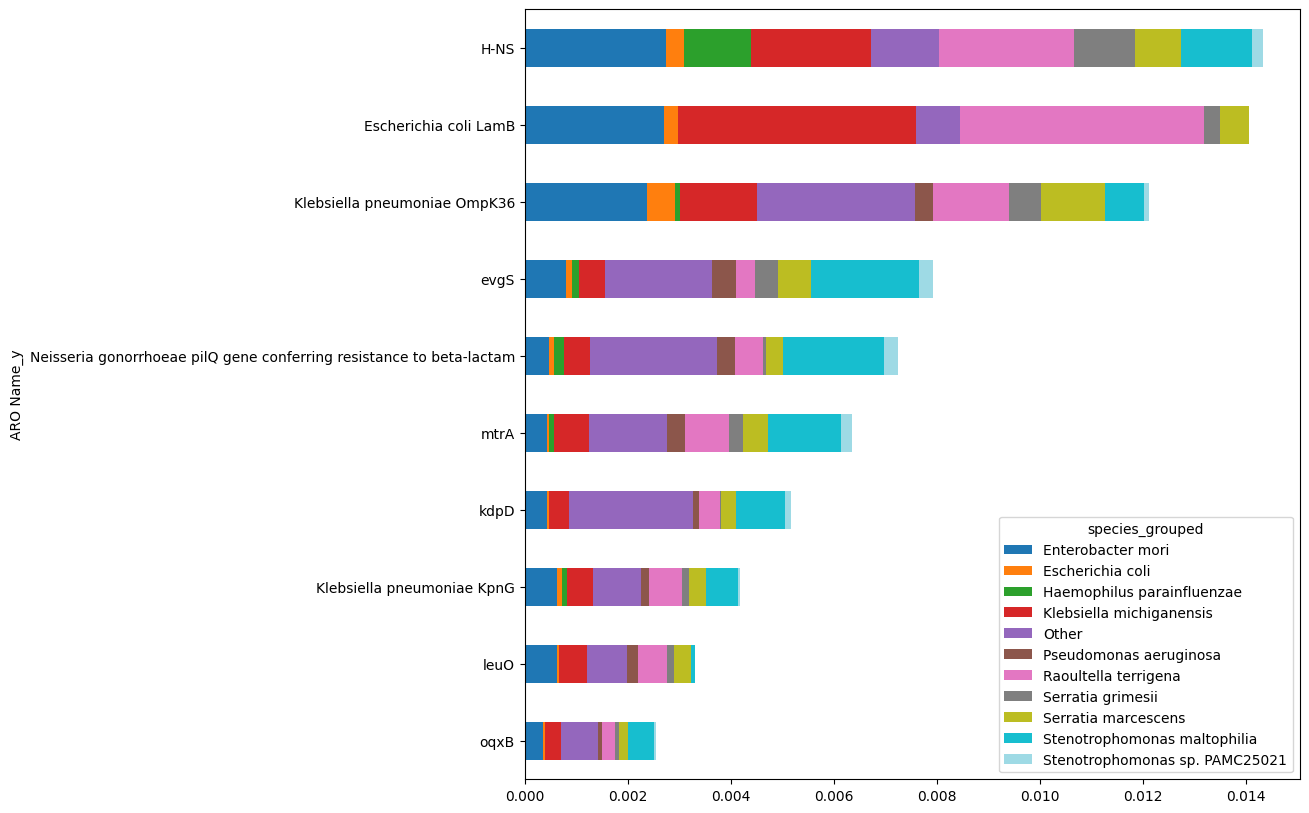

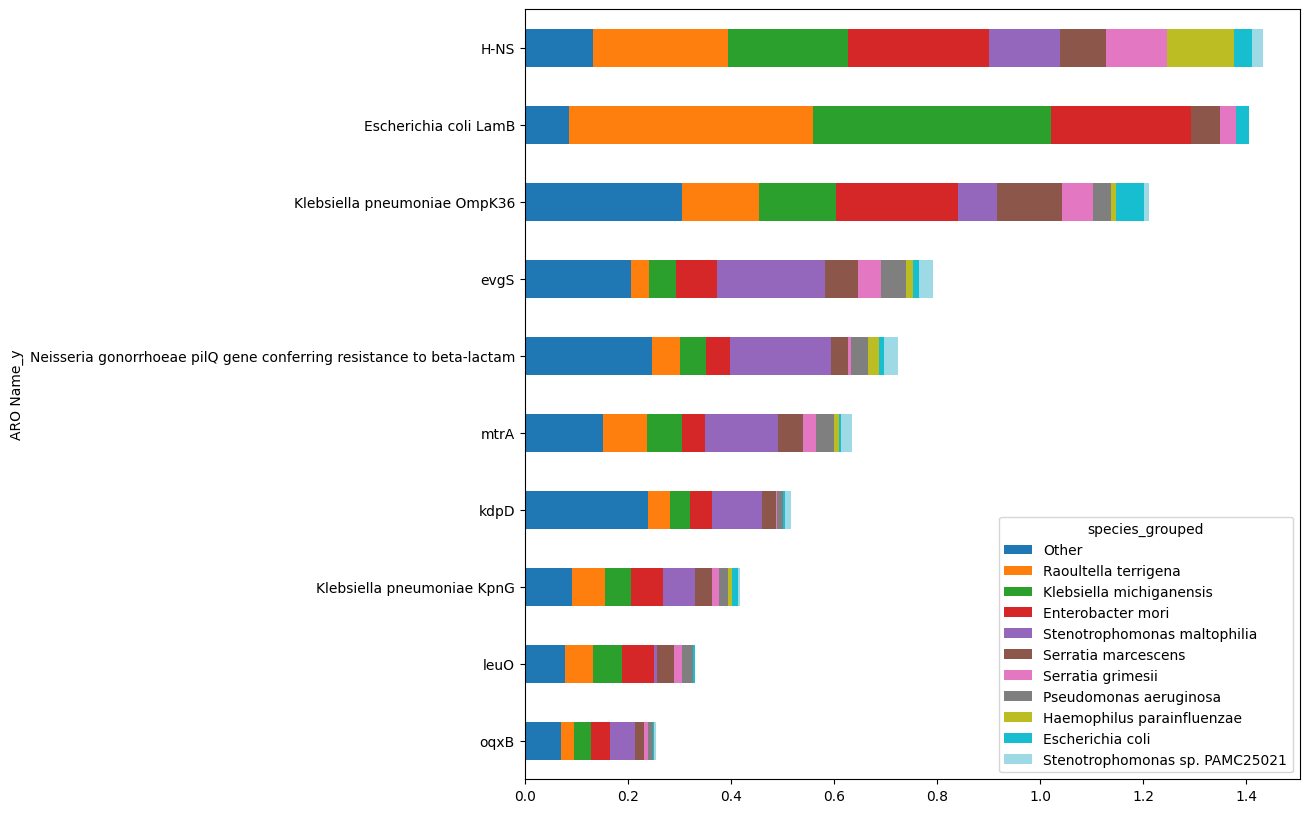

In [21]:
filtered_df = dfm[dfm['IPS_sig_group']== '20_year']
filtered_df

unique_species= len(filtered_df['species'].unique())
unique_species

unique_genes = len(filtered_df['feature_id'].unique())
unique_genes

pivot_df = (
    filtered_df.dropna(subset=['ARO Name_y'])
               .groupby(['ARO Name_y', 'species'])
               .size()       # count of each species per module
               .div(unique_genes)  # divide by your number
               .unstack(fill_value=0)  # make species columns
)
pivot_df

long_df = pivot_df.reset_index().melt(
    id_vars='ARO Name_y',       # keep 'module' as identifier
    var_name='species',     # name of the column for species
    value_name='ratio'      # name of the column for the values (size / unique_genes)
)

long_df

# get top representative species

# Step 3: compute total abundance per species
species_totals = long_df.groupby('species')['ratio'].sum()

# Step 4: identify top 10 species
top_species = species_totals.nlargest(10).index

# Step 5: group species not in top 10 into 'Other'
long_df['species_grouped'] = long_df['species'].where(
    long_df['species'].isin(top_species),
    'Other'
)

# Step 6: aggregate ratios per module and grouped species
final_long_df = (
    long_df.groupby(['ARO Name_y', 'species_grouped'])['ratio']
           .sum()
           .reset_index()
)

# Optional Step 7: pivot back to wide format (top 10 + Other as columns)
final_wide_df = final_long_df.pivot(
    index='ARO Name_y',
    columns='species_grouped',
    values='ratio'
).fillna(0)


#get top most prevalent pathways
final_wide_df_top25 = (
    final_wide_df.assign(total=final_wide_df.sum(axis=1))
                 .sort_values('total', ascending=True)  # highest totals first
                 .tail(10)                               # keep top 25 rows
                 .drop(columns='total')                  # remove helper column
)

# Step 2: plot
final_wide_df_top25.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

species_totals = final_wide_df_top25.sum().sort_values(ascending=False)

final_wide_df_top25 = final_wide_df_top25 * 100


# Step 2: reorder columns by total abundance
final_wide_df_top25_sorted_cols = final_wide_df_top25[species_totals.index]

# Step 3: plot
final_wide_df_top25_sorted_cols.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

<Axes: ylabel='ARO Name_y'>

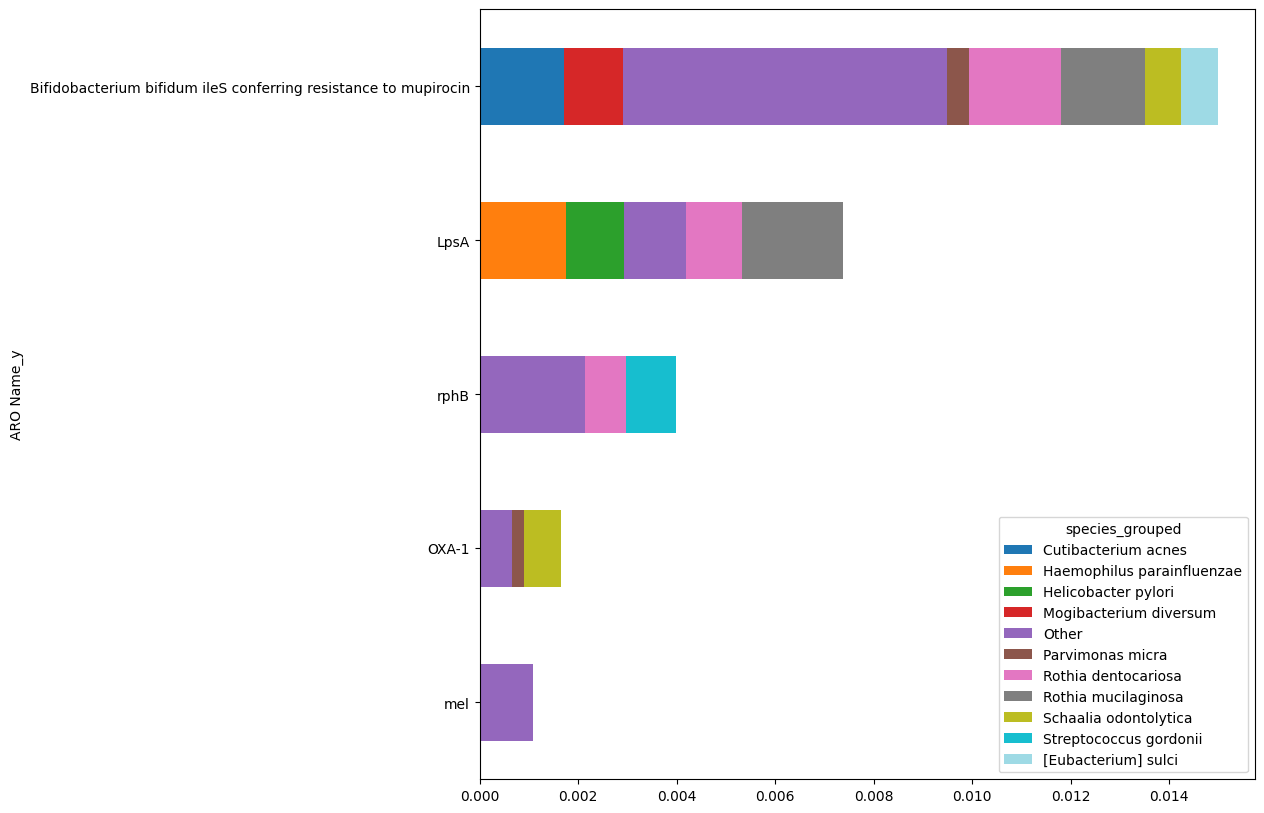

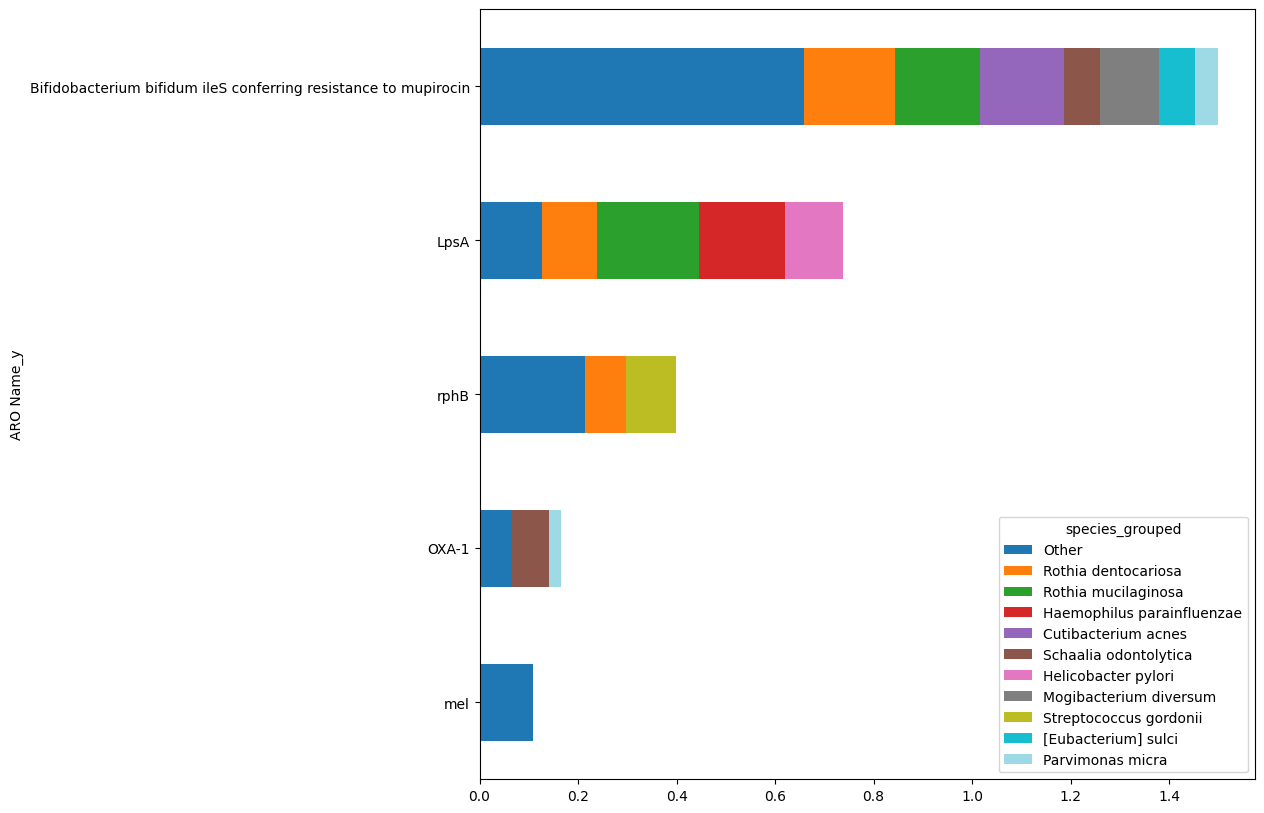

In [22]:
filtered_df = dfm[dfm['IPS_sig_group']== '26_year']
filtered_df

unique_species= len(filtered_df['species'].unique())
unique_species

unique_genes = len(filtered_df['feature_id'].unique())
unique_genes

pivot_df = (
    filtered_df.dropna(subset=['ARO Name_y'])
               .groupby(['ARO Name_y', 'species'])
               .size()       # count of each species per module
               .div(unique_genes)  # divide by your number
               .unstack(fill_value=0)  # make species columns
)
pivot_df

long_df = pivot_df.reset_index().melt(
    id_vars='ARO Name_y',       # keep 'module' as identifier
    var_name='species',     # name of the column for species
    value_name='ratio'      # name of the column for the values (size / unique_genes)
)

long_df

# get top representative species

# Step 3: compute total abundance per species
species_totals = long_df.groupby('species')['ratio'].sum()

# Step 4: identify top 10 species
top_species = species_totals.nlargest(10).index

# Step 5: group species not in top 10 into 'Other'
long_df['species_grouped'] = long_df['species'].where(
    long_df['species'].isin(top_species),
    'Other'
)

# Step 6: aggregate ratios per module and grouped species
final_long_df = (
    long_df.groupby(['ARO Name_y', 'species_grouped'])['ratio']
           .sum()
           .reset_index()
)

# Optional Step 7: pivot back to wide format (top 10 + Other as columns)
final_wide_df = final_long_df.pivot(
    index='ARO Name_y',
    columns='species_grouped',
    values='ratio'
).fillna(0)


#get top most prevalent pathways
final_wide_df_top25 = (
    final_wide_df.assign(total=final_wide_df.sum(axis=1))
                 .sort_values('total', ascending=True)  # highest totals first
                 .tail(10)                               # keep top 25 rows
                 .drop(columns='total')                  # remove helper column
)

# Step 2: plot
final_wide_df_top25.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)

species_totals = final_wide_df_top25.sum().sort_values(ascending=False)

final_wide_df_top25 = final_wide_df_top25 * 100


# Step 2: reorder columns by total abundance
final_wide_df_top25_sorted_cols = final_wide_df_top25[species_totals.index]

# Step 3: plot
final_wide_df_top25_sorted_cols.plot.barh(
    stacked=True,
    figsize=(10, 10),
    colormap='tab20'
)